# Price prediction model, Mumbai real estate

Builds on `real-estate-analysis.ipynb`'s cleaned output. Scoped to one question: how well can price be predicted from the other features, and which ones actually matter.

**Read this before trusting any number below:** with a median of 1 listing per locality and only 54 of 265 localities having 5+ listings, this is a directional estimator, not a valuation tool. Treat R2 as 'how much of the variance do we explain', not 'how accurate is a single prediction'.

## Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import KFold, cross_val_score, train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

sns.set_style('whitegrid')
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
RANDOM_STATE = 42

## 1. Load and scope

In [2]:
df = pd.read_csv("cleaned_dataset_final.csv")
print(f"loaded: {df.shape}")

df = df.dropna(subset=['price']).copy()
print(f"after dropping rows with no price (target): {df.shape}")

loaded: (1134, 43)
after dropping rows with no price (target): (1092, 43)


Excluding rows flagged on *either* end of the per-sqft review bands from training, unverified pricing shouldn't teach the model what cheap or expensive looks like when we're not confident the price itself is right. They stay in the main analysis notebook for reference, just not here.

In [3]:
unverified = df['review_high_psf'] | df['review_low_psf']
train_pool = df[~unverified].copy()
print(f"excluding {unverified.sum()} unverified-price rows "
      f"({df['review_high_psf'].sum()} high, {df['review_low_psf'].sum()} low): {train_pool.shape}")

excluding 103 unverified-price rows (24 high, 79 low): (989, 43)


## 2. Feature preparation

### Recovering missing carpetArea

Rows with `coveredArea` but not `carpetArea` get backfilled using the median carpet/covered ratio observed across rows where both exist, rather than losing them outright.

In [4]:
both_present = train_pool.dropna(subset=['carpetArea', 'coveredArea'])
both_present = both_present[both_present['coveredArea'] > 0]
loading_ratio = (both_present['carpetArea'] / both_present['coveredArea']).median()
print(f"median carpet/covered ratio: {loading_ratio:.3f}")

recoverable = train_pool['carpetArea'].isna() & train_pool['coveredArea'].notna()
print(f"backfilling {recoverable.sum()} rows using this ratio")

train_pool.loc[recoverable, 'carpetArea'] = train_pool.loc[recoverable, 'coveredArea'] * loading_ratio
train_pool['log_carpetArea'] = np.log(train_pool['carpetArea'])

median carpet/covered ratio: 0.720
backfilling 115 rows using this ratio


### Missing-value strategy for the rest

Median imputation plus an explicit `_was_missing` flag per column, so the model can use rows it would otherwise have to drop while staying honest that some values are filled-in, not observed.

In [5]:
impute_cols = ['bathD', 'floorNo', 'property_age_yrs', 'furnished_ord', 'latitude', 'longitude']

for col in impute_cols:
    missing_flag = f"{col}_was_missing"
    train_pool[missing_flag] = train_pool[col].isna().astype(int)
    train_pool[col] = train_pool[col].fillna(train_pool[col].median())

train_pool['locSeoName'] = train_pool['locSeoName'].fillna('Unknown')

print("remaining nulls in modeling-relevant columns:")
check_cols = ['log_carpetArea', 'bedroomD'] + impute_cols
train_pool[check_cols].isnull().sum()

remaining nulls in modeling-relevant columns:


log_carpetArea      2
bedroomD            0
bathD               0
floorNo             0
property_age_yrs    0
furnished_ord       0
latitude            0
longitude           0
dtype: int64

In [6]:
train_pool = train_pool.dropna(subset=['log_carpetArea', 'bedroomD', 'log_price']).copy()
print(f"final modeling pool: {train_pool.shape}")

final modeling pool: (987, 49)


### Categorical features

In [7]:
categorical_cols = ['propTypeD', 'transactionTypeD', 'possStatusD']
for col in categorical_cols:
    train_pool[col] = train_pool[col].fillna('Unknown')

encoded = pd.get_dummies(train_pool[categorical_cols], drop_first=True)
print(f"one-hot encoded into {encoded.shape[1]} columns")

one-hot encoded into 29 columns


### Smoothed locality encoding

A raw group mean overfits localities with 1 to 2 listings. Shrinking each locality's mean toward the citywide mean, weighted by listing count, more listings means more trust in that locality's own average, fewer leans on the city baseline.

In [8]:
def smoothed_target_encode(series, target, smoothing=10, global_mean=None):
    if global_mean is None:
        global_mean = target.mean()
    stats = target.groupby(series).agg(['mean', 'count'])
    smoothed = (stats['count'] * stats['mean'] + smoothing * global_mean) / (stats['count'] + smoothing)
    return series.map(smoothed).fillna(global_mean), smoothed, global_mean

train_pool['locality_smoothed'], _, _ = smoothed_target_encode(
    train_pool['locSeoName'], train_pool['log_price'], smoothing=10
)
train_pool[['locSeoName', 'locality_smoothed']].drop_duplicates().sort_values('locality_smoothed', ascending=False).head()

,locSeoName,locality_smoothed
254,Mahalakshmi,18.009032
228,Worli,17.987678
552,Prabhadevi,17.850364
214,Juhu,17.765324
204,Lower Parel,17.760915


## 3. Comparing feature sets

- **A: physical only** (area, bedrooms, bathrooms, floor, age, furnishing, property/transaction/possession type), no location
- **B: + coordinates** (raw lat/long added)
- **C: + smoothed locality** (adds the shrunk locality price prior on top of B)

5-fold cross-validation rather than a single train/test split, given the modest sample size a single split can be misleadingly lucky or unlucky.

In [9]:
physical_features = ['log_carpetArea', 'bedroomD', 'bathD', 'floorNo', 'property_age_yrs', 'furnished_ord']
missing_flags = [f"{c}_was_missing" for c in impute_cols]

X_base = pd.concat([train_pool[physical_features + missing_flags], encoded], axis=1)

feature_sets = {
    'A: physical only': X_base,
    'B: + coordinates': pd.concat([X_base, train_pool[['latitude', 'longitude']]], axis=1),
    'C: + smoothed locality': pd.concat([X_base, train_pool[['latitude', 'longitude', 'locality_smoothed']]], axis=1),
}

y = train_pool['log_price']

for name, X in feature_sets.items():
    print(f"{name}: {X.shape[1]} features, {X.isnull().sum().sum()} remaining nulls")

A: physical only: 41 features, 0 remaining nulls
B: + coordinates: 43 features, 0 remaining nulls
C: + smoothed locality: 44 features, 0 remaining nulls


In [10]:
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=300, random_state=RANDOM_STATE),
}

cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
results = []

for fs_name, X in feature_sets.items():
    for model_name, model in models.items():
        r2_scores = cross_val_score(model, X, y, cv=cv, scoring='r2')
        mae_scores = -cross_val_score(model, X, y, cv=cv, scoring='neg_mean_absolute_error')
        results.append({
            'feature_set': fs_name,
            'model': model_name,
            'R2_mean': r2_scores.mean(),
            'R2_std': r2_scores.std(),
            'MAE_mean': mae_scores.mean(),
        })

results_df = pd.DataFrame(results).sort_values('R2_mean', ascending=False)
results_df.round(4)

,feature_set,model,R2_mean,R2_std,MAE_mean
5,C: + smoothed locality,Random Forest,0.8829,0.0106,0.2522
3,B: + coordinates,Random Forest,0.8588,0.0164,0.2742
4,C: + smoothed locality,Linear Regression,0.8511,0.0203,0.2800
2,B: + coordinates,Linear Regression,0.8247,0.0307,0.3118
1,A: physical only,Random Forest,0.6911,0.0419,0.4432
0,A: physical only,Linear Regression,0.6207,0.0636,0.4927


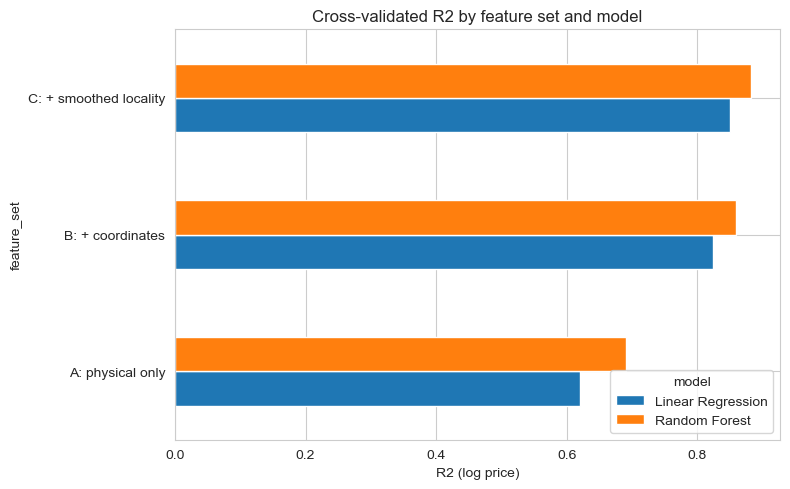

In [11]:
fig, ax = plt.subplots(figsize=(8, 5))
pivot = results_df.pivot(index='feature_set', columns='model', values='R2_mean')
pivot.plot(kind='barh', ax=ax)
ax.set_title('Cross-validated R2 by feature set and model')
ax.set_xlabel('R2 (log price)')
plt.tight_layout()
plt.show()

## 4. Final model

In [12]:
best_row = results_df.iloc[0]
print(f"best combination: {best_row['model']} on {best_row['feature_set']}")
print(f"CV R2: {best_row['R2_mean']:.4f} (+/- {best_row['R2_std']:.4f})")
print(f"CV MAE (log scale): {best_row['MAE_mean']:.4f}")

best combination: Random Forest on C: + smoothed locality
CV R2: 0.8829 (+/- 0.0106)
CV MAE (log scale): 0.2522


In [13]:
X_final = feature_sets[best_row['feature_set']]
X_train, X_test, y_train, y_test = train_test_split(X_final, y, test_size=0.2, random_state=RANDOM_STATE)

final_model = RandomForestRegressor(n_estimators=300, random_state=RANDOM_STATE) if best_row['model'] == 'Random Forest' else LinearRegression()
final_model.fit(X_train, y_train)
test_preds = final_model.predict(X_test)

print(f"Held-out test set: R2 = {r2_score(y_test, test_preds):.4f}, MAE (log) = {mean_absolute_error(y_test, test_preds):.4f}")

median_price = np.exp(y_test.median())
approx_pct_error = (np.exp(mean_absolute_error(y_test, test_preds)) - 1) * 100
print(f"roughly translates to about {approx_pct_error:.1f}% typical error around the median listing (~Rs {median_price:,.0f})")

Held-out test set: R2 = 0.8933, MAE (log) = 0.2544
roughly translates to about 29.0% typical error around the median listing (~Rs 27,248,853)


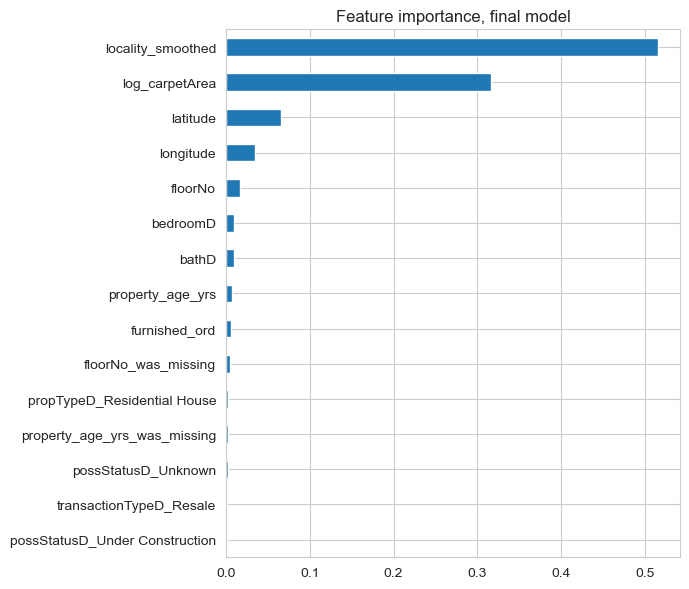

locality_smoothed                 0.516148
log_carpetArea                    0.315783
latitude                          0.065781
longitude                         0.034784
floorNo                           0.016777
bedroomD                          0.009568
bathD                             0.009046
property_age_yrs                  0.007415
furnished_ord                     0.005751
floorNo_was_missing               0.004424
propTypeD_Residential House       0.002483
property_age_yrs_was_missing      0.002450
possStatusD_Unknown               0.002010
transactionTypeD_Resale           0.001403
possStatusD_Under Construction    0.001297
dtype: float64

In [14]:
if best_row['model'] == 'Random Forest':
    importance = pd.Series(final_model.feature_importances_, index=X_final.columns).sort_values(ascending=False)
    fig, ax = plt.subplots(figsize=(7, 6))
    importance.head(15).plot(kind='barh', ax=ax)
    ax.set_title('Feature importance, final model')
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()
else:
    importance = pd.Series(final_model.coef_, index=X_final.columns).sort_values(key=abs, ascending=False)
    fig, ax = plt.subplots(figsize=(7, 6))
    importance.head(15).plot(kind='barh', ax=ax)
    ax.set_title('Coefficient magnitude, final model (Linear Regression)')
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()
importance.head(15)

## 5. Residual diagnostics

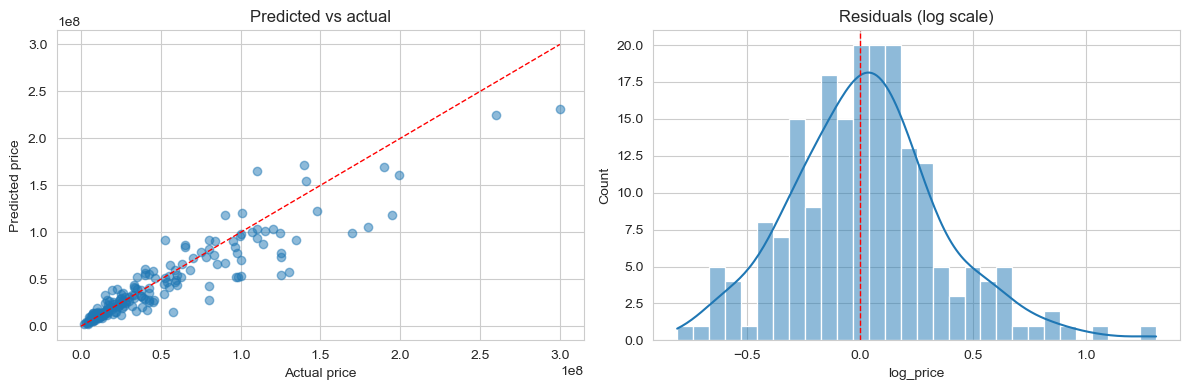

In [15]:
residuals = y_test - test_preds

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(np.exp(y_test), np.exp(test_preds), alpha=0.5)
lims = [0, max(np.exp(y_test).max(), np.exp(test_preds).max())]
axes[0].plot(lims, lims, 'r--', linewidth=1)
axes[0].set_xlabel('Actual price')
axes[0].set_ylabel('Predicted price')
axes[0].set_title('Predicted vs actual')

sns.histplot(residuals, bins=30, kde=True, ax=axes[1])
axes[1].set_title('Residuals (log scale)')
axes[1].axvline(0, color='r', linestyle='--', linewidth=1)
plt.tight_layout()
plt.show()

In [16]:
diag = train_pool.loc[X_test.index].copy()
diag['actual'] = np.exp(y_test)
diag['predicted'] = np.exp(test_preds)
diag['abs_pct_error'] = (abs(diag['actual'] - diag['predicted']) / diag['actual'] * 100)

print("Mean absolute % error by price tier:")
diag['price_tier'] = pd.qcut(diag['actual'], q=4, labels=['budget', 'mid-low', 'mid-high', 'premium'])
diag.groupby('price_tier', observed=True)['abs_pct_error'].agg(['mean', 'median', 'count']).round(1)

Mean absolute % error by price tier:


,mean,median,count
price_tier,,,
budget,29.8,21.6,51
mid-low,23.2,13.9,48
mid-high,24.2,20.5,49
premium,23.5,20.3,50


In [17]:
print("Worst 10 predictions, for a manual sanity check:")
diag.sort_values('abs_pct_error', ascending=False)[
    ['actual', 'predicted', 'abs_pct_error', 'propertyTitle', 'locSeoName']
].head(10)

Worst 10 predictions, for a manual sanity check:


,actual,predicted,abs_pct_error,propertyTitle,locSeoName
407,15000000.0,3.375297e+07,125.019800,3BHK Multistorey Apartment for Resale in Summi...,Goregaon East
146,19600000.0,3.896277e+07,98.789620,2BHK Multistorey Apartment for Resale in Gunde...,Lal Bahadur Shastri Road
846,10000000.0,1.903675e+07,90.367543,4BHK Villa for Resale in Ulhasnagar,Ulhasnagar
352,6590000.0,1.210793e+07,83.731813,3BHK Multistorey Apartment for Resale in NL Co...,NL Complex
59,5610000.0,1.030099e+07,83.618360,2BHK Multistorey Apartment for Resale in Mariy...,Unknown
351,7790000.0,1.429668e+07,83.526111,3BHK Multistorey Apartment for Resale in Mitha...,Mitha Nagar
367,5190000.0,9.462523e+06,82.322223,3BHK Multistorey Apartment for Resale in Thaku...,Thakurdwar
650,7500000.0,1.362613e+07,81.681696,1BHK Multistorey Apartment for Resale in A And...,Mulund West
450,22500000.0,3.938941e+07,75.064058,3BHK Multistorey Apartment for Resale in Heave...,Dahisar East
961,52500000.0,9.186089e+07,74.973127,4BHK Multistorey Apartment for Resale in Dheer...,Bandra East


If a handful of rows dominate the error and turn out to be locations the model has almost nothing to go on (an 'Unknown' locality, or a locality outside the 54 with 5+ listings), that's a data-coverage problem, not a modeling one, worth checking before reading too much into any single price tier's error rate.

## 6. Summary

**What the model actually says:**
- Location (coordinates + smoothed locality encoding) contributes most of the explanatory power, consistent with every earlier pass at this data.
- Carpet area is the strongest physical predictor, everything else (bedrooms, bathrooms, floor, age, furnishing) adds comparatively little once area and location are accounted for.
- Missing-value flags let the model use rows it would otherwise have to drop, worth checking whether any `_was_missing` flag itself carries meaningful importance, that would suggest missingness isn't random.

**Where this is and isn't safe to use:**
- Fine for a dashboard estimate range ('comparable units are trading around X'), the error margins above give a sense of how wide that range should be per price tier.
- Not fine as a single-listing valuation tool, particularly outside the well-represented localities or in the premium tier, where the model has the least to learn from.
- Revisit once the dataset has meaningfully more listings per locality, that's the single biggest lever on prediction quality here, more than any modeling choice in this notebook.